# 7 Intervalos de Confianza

### Un intervalo de confianza bilateral $[\hat{\theta}_L, \hat{\theta}_U]$ a un nivel de confianza de $(1-\alpha)100$% satisface 
\begin{align}
 \mathbb{P}(\hat{\theta}_L\leq \theta \leq \hat{\theta}_U)=1-\alpha,
\end{align}
### donde $\hat{\theta}_L$ se denomina límite confianza inferior y $\hat{\theta}_U$ límite de confianza superior.

Intervalos de confianza unilaterales:
    a) inferior $[\hat{\theta}, \infty):$$\newline$ 
    \begin{align}
    \mathbb{P}(\hat{\theta}_L\leq \theta)=1-\alpha.
    \end{align}
    b) superior  $(-\infty, \hat{\theta}_U]:$$\newline$
    \begin{align}
\mathbb{P}(\theta \leq \hat{\theta}_U)=1-\alpha.
\end{align}

<img src="int-conf.png">

### Un método para encontrar intervalos de confianza se denomina $\textit{método de pivote}$. Éste consiste en determinar una cantidad que actúe como pivote y que posea las dos características siguientes:

### 1. Que sea una función de las medidas muestrales y el parámetro desconocido $\theta$, donde $\theta$ sea la única cantidad desconocida.

### 2. Que su distribución de probabilidad no dependa del parámetro $\theta$.

### $\textbf{Ejemplo}$ Intervalos de confianza para el parámetro $\mu$ de una población normal con $\sigma$ conocida.

### Sea $X$ una v.a. normal con media poblacional $\mu$ desconocida y desviación poblacional $\sigma$ conocida. Sea $X_1, \dots, X_n$ una muestra aleatoria de $X$, con media muestral $\bar{X}$. Determinar un intervalo de confianza bilateral para $\mu$ con nivel de confianza $1-\alpha$. Para fines prácticos supongamos $\alpha=0.05$.

### De acuerdo con la definición buscamos un intervalo $[\hat{\theta}_L, \hat{\theta}_U]$ tal que
\begin{align}
\mathbb{P}(\hat{\theta}_L\leq \theta \leq \hat{\theta}_U)=1-\alpha,
\end{align}

Un candidato a pivote es:
    \begin{align}
    Z=\frac{\bar{X}-\mu}{\sigma/\sqrt{n}}\sim N(0,1)
    \end{align}

Entonces
\begin{align}
\mathbb{P}(-a \leq \frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \leq a)=0.95
\end{align}

así, $0.95=\mathbb{P}(-a \leq Z \leq a)=\varPhi(a)-\varPhi(-a)=2\varPhi(a)-1$, $$\varPhi(a)=0.975.$$

In [1]:
from scipy.stats import norm
norm.ppf(0.975)

1.959963984540054

### Entonces, $a=1.96$. De este modo, 
\begin{align}
0.95=\mathbb{P}(-1.96 \leq \frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \leq 1.96)
\end{align}

### Despejando $\mu$, obtenemos

\begin{align}
\mathbb{P}(\bar{X}-1.96\frac{\sigma}{\sqrt{n}}\leq \mu \leq \bar{X}+1.96\frac{\sigma}{\sqrt{n}})=0.95.
\end{align}

### Por lo tanto, la probabilidad que la media poblacional $\mu$ de $X$ se encuentre dentro del intervalo
\begin{align}
(\bar{X}-1.96\frac{\sigma}{\sqrt{n}}, \bar{X}+1.96\frac{\sigma}{\sqrt{n}})
\end{align}
### es 0.95: es un intervalo de confianza del 95%.

En general, si una población $X$ Normal con $\mu$ desconocida y $\sigma$-conocida, tiene como intervalo de confianza de $(1-\alpha)$100%:
    \begin{align}
    (\bar{X}-z_{1-\frac{\alpha}{2}}\frac{\sigma}{\sqrt{n}}, \bar{X}+z_{1-\frac{\alpha}{2}}\frac{\sigma}{\sqrt{n}})
    \end{align}
donde $z_{1-\frac{\alpha}{2}}$ es el $(1-\frac{\alpha}{2})$-cuantil de la Normal estandar, i.e. $\mathbb{P}(Z\leq z_{1-\frac{\alpha}{2}})=1-\frac{\alpha}{2}$ . 

# Intervalos de confianza para el parámetro $\mu$ de una población con $\sigma$ conocida y tamaño muestral grande $n$.

In [3]:
import numpy as np
from scipy.stats import norm

def ICZ(x, sigma, alpha):
    n = len(x)
    media = np.mean(x)
    z = norm.ppf(1 - alpha/2)
    
    inferior = media - z * (sigma / np.sqrt(n))
    superior = media + z * (sigma / np.sqrt(n))
    
    return inferior, superior

In [4]:
x = norm.rvs(50, 5, 30)
inferior, superior = ICZ(x, 5, 0.05)
print(inferior, superior)

48.63703928731492 52.21542757474923


In [5]:
mu = 1.5
sigma = 1
poblacion = norm.rvs(mu, sigma, 10000)

In [6]:
import random
M = np.zeros((100, 2))
alpha = 0.05
for i in range(100):
    muestra = random.choices(poblacion, k=50)
    M[i, :] = ICZ(muestra, sigma, alpha)

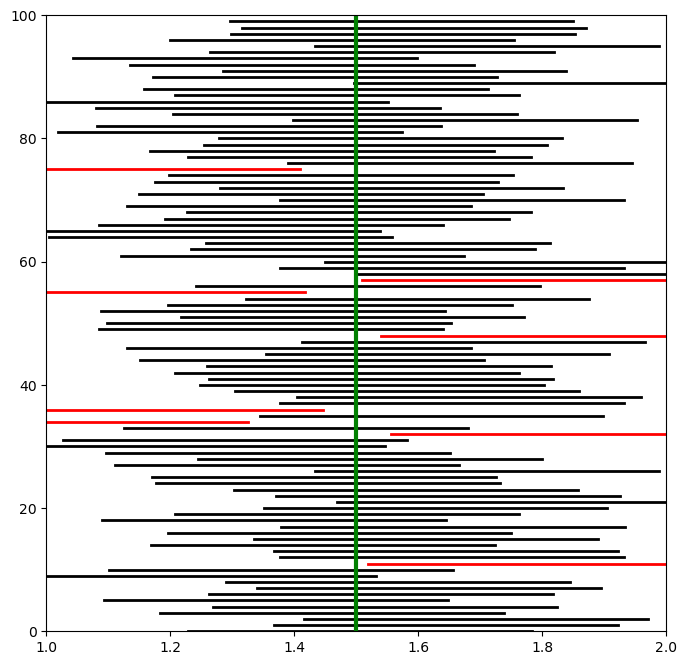

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot([], [])  
plt.xlim(1,2)
plt.ylim(0,100)

def intervalos(i):
    color = "black"
    
    if (mu < M[i, 0]) or (mu > M[i, 1]):
        color = "red"
        
    plt.plot([M[i, 0], M[i, 1]], [i, i], color=color, linewidth=2)

for i in range(100):
    intervalos(i)

plt.axvline(x=mu, color="green", linewidth=3)
plt.show()

## Intervalos de confianza para el parámetro $\mu$ de una población normal con $\sigma$ desconocida.

En este caso el estadístico a aplicar es
\begin{align}
t=\frac{\bar{X}-\mu}{S_X/\sqrt{n}}
\end{align}

el cual corresponde a un pivote y su distribución corresponde a una densidad t-Student con $n-1$ g.l. y 
\begin{align}
S_X^2=\frac{1}{n-1}\sum_{k=1}^{n}(X_k-\bar{X})^2
\end{align}

Para este caso siguiendo las mismas ideas del caso anterior se puede comprobar que in intervalo de confianza para $\mu$ de $(1-\alpha)$100% es:
    \begin{align}
    (\bar{X}-t_{1-\frac{\alpha}{2}}\frac{S_X}{\sqrt{n}}, \bar{X}+t_{1-\frac{\alpha}{2}}\frac{S_X}{\sqrt{n}})
    \end{align}

donde $t_{1-\frac{\alpha}{2}}$ corresponde al cuantil $(1-\frac{\alpha}{2})$ de una $t_{n-1}$.

In [13]:
from scipy.stats import ttest_1samp
import seaborn as sns

iris = sns.load_dataset('iris')
confianza= 0.90

muestra_iris=iris.sample(30, replace=True)
long_petalo_muestra=muestra_iris['petal_length']
resultado_t_test = ttest_1samp(long_petalo_muestra, popmean=np.mean(long_petalo_muestra))
resultado_t_test.confidence_interval(confianza)

ConfidenceInterval(low=3.662605759804357, high=4.690727573528976)

### $\textbf{Ejercicio}$ calcular el intervalo de confianza para $\mu$ de una población normal con $\sigma$ desconocida con los valores siguientes: $n=24$, $\bar{x}=518$, $S=40$, $1-\alpha=0.9$.

# Intervalos de confianza para el parámetro $p$ de una población de Bernoulli

En el campo de la estadística, la distribución binomial se utiliza habitualmente en diversas aplicaciones, especialmente en situaciones en las que los resultados de interés pueden clasificarse en dos, es decir, un éxito o un fracaso. Las proporciones binomiales y sus intervalos de confianza se utilizan mucho en los ensayos clínicos para evaluar la tasa de respuesta y a veces se emplean en los demás ensayos para evaluar la incidencia global de acontecimientos adversos.  

Sea $\newline$

$\bullet$ $X$ una v.a. Bernoulli con $p$ desconocido. $\newline$

$\bullet$ $X_1, X_2, ...X_n$ una muestra aleatoria de $X$.

Un intervalo de confianza $(p_0,p_1)$ del $(1−\alpha)$100% nivel de confianza para $p$ de una población $X$ de Bernoulli se obtiene encontrando el $p_0$ más grande y el $p_1$ más pequeño tales que

<img src="Clopper.png">

Un método para determinar dicho intervalo es el de Clopper-Pearson: $$(B_{\alpha/2}(k, n-k+1), B_{1-\alpha/2}(k+1, n-k)$$

$\bf{Ejemplo}$ Encontrar un intervalo de confianza para la proporción de flores de especie "setosa" dada una muestra de 60 flores. 

In [14]:
from scipy.stats import binomtest

flores_elegidas=iris.sample(60, replace=True)
numero_flores_setosa = (flores_elegidas['species'] == 'setosa').sum()
print(numero_flores_setosa)
intervalo= binomtest(numero_flores_setosa, 60, 0.5, 'two-sided')

intervalo.proportion_ci(0.95)

21


ConfidenceInterval(low=0.23132642214868276, high=0.48402800937056695)

In [16]:
(iris['species']=='setosa').sum()/150

0.3333333333333333

### $\bf{Ejercicio}$ Encontrar un intervalo de confianza para la proporción de sobrevivientes ("alive") de la base de datos "titanic", dada una muestra de 200 individuos.

# Intervalo de confianza para la varianza de una población normal

### Consideramos una v.a. $X$ normal con media $\mu$ y varianza $\sigma^2$ desconocidas. Sea $X_1, ..., X_n$ una muestra aleatoria de  $X$ y varianza muestral $S^2$. Bajo estas condiciones un estadístico pivote es: $$\frac{(n-1)S^2}{\sigma^2} $$

### la cual tiene una distribucíon $\chi^2$ con $n-1$ grados de libertad.

### De este modo podemos encontrar un intevalo de confianza: $$ \left(\frac{(n-1)S^2}{\chi^{2}_{1-\frac{\alpha}{2}}},\frac{(n-1)S^2}{\chi^{2}_{\frac{\alpha}{2}}} \right)$$


### $\bf{Ejemplo}$: Un algoritmo probabilístico depende de la semilla de aleatorización que se genera en cada paso. Para saber si la semilla influye mucho en el resultado se ejecuta el algoritmo varias veces hasta obtener un resultado similar y se estudia la varianza de su tiempo de ejecución.

### Queremos ver si la desviación típica $\sigma$ es menor o igual a 30.

### Se supone que la distribución del tiempo de ejecución del algoritmo es aproximadamente normal.

In [17]:
from scipy.stats import chi2


tiempo = np.array([12, 13, 13, 14, 14, 14, 15, 15, 16, 17, 17, 18, 18, 19, 19, 
                   25, 25, 26, 27, 30, 33, 34, 35, 40, 40, 51, 51, 58, 59, 83])

n = len(tiempo)
alpha = 0.05

var_muestral_tiempo = np.var(tiempo, ddof=1)
cuantil_izquierda = chi2.ppf(1 - alpha/2, df=n-1)
cuantil_derecha = chi2.ppf(alpha/2, df=n-1)

valor_izquierdo = (n - 1) * var_muestral_tiempo / cuantil_izquierda
valor_derecho = (n - 1) * var_muestral_tiempo / cuantil_derecha

np.sqrt([valor_izquierdo, valor_derecho])

array([13.82977493, 23.34431758])

# Bootstrap o remuestreo 

### La idea principal del Bootstrap es realizar múltiples re-muestreos (con reemplazo) de la muestra original para obtener una aproximación empírica de la distribución de la estadística que estás interesado en estudiar. En intervalos de confianza se pueden seguir los puntos siguientes: $\newline$

### $\bullet$ Remuestrear la muestra: tomar varias muestras aleatorias simples de la muestra de la que disponemos, cada una de ellas del mismo tamaño que la muestra original.

### $\bullet$ Calcular el estimador sobre cada una de estas submuestras.

### $\bullet$ Organizar los resultados en un vector.

### $\bullet$ Usar este vector para calcular un intervalo de confianza.

### $\textbf{Método}$ $\textbf{de}$ $\textbf{los}$ $\textbf{percentiles}$. en el que se toman como extremos del intervalo de confianza del  $(1-\alpha)100$% los cuantiles de orden $\alpha/2$ y $1-\alpha/2$ del vector de estimadores.

In [10]:
datos = np.array([
            81.372918, 25.700971, 4.942646, 43.020853, 81.690589, 51.195236,
            55.659909, 15.153155, 38.745780, 12.610385, 22.415094, 18.355721,
            38.081501, 48.171135, 18.462725, 44.642251, 25.391082, 20.410874,
            15.778187, 19.351485, 20.189991, 27.795406, 25.268600, 20.177459,
            15.196887, 26.206537, 19.190966, 35.481161, 28.094252, 30.305922
        ])

<function matplotlib.pyplot.show(close=None, block=None)>

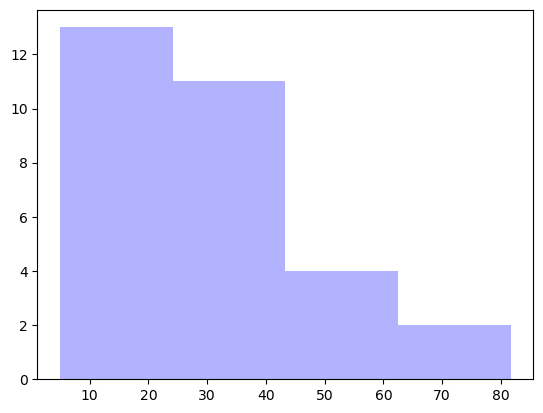

In [11]:
plt.hist(datos, bins='scott', color='blue', alpha=0.3)
plt.show

In [12]:
def bootstraping(x, fun_estadistico, n_iteraciones):
    
    n = len(x)
    dist_boot = np.empty(n_iteraciones)
    
    for i in range(n_iteraciones):
        resample = random.choices(x, k=n)
        dist_boot[i] = fun_estadistico(resample)
        
    return dist_boot

In [13]:
def media(x):
    
    estadistico = np.mean(x)
    
    return estadistico

In [14]:
dist_boot = bootstraping(x = datos, fun_estadistico = media, n_iteraciones   = 10000)

In [15]:
dist_boot

array([31.0604415 , 24.32036777, 31.20809323, ..., 31.91157707,
       29.98828013, 25.15546243])

In [16]:
np.quantile(dist_boot, [0.025, 0.975])

array([24.96709922, 37.86535286])

### $\textbf{Ejercicio}$: Encontrar un intervalo de confianza para la desviación de la anchura del pétalo de la tabla de datos iris. (vía bootstrap)

### $\textbf{Ejercicio:}$ Suponga que obtenemos una observación $Y$ de una distribución exponencial con media $\theta$. Utilice $Y$ para construir un intervalo de confianza para $\theta$ con un coeficiente de confianza de 0.90.  